# CTIG v1.4 — Xem từng bước của pipeline

**Settings (panel phải):** Accelerator = GPU T4 x2 (hoặc T4), Internet = On.

Mỗi cell dưới đây hiện đầu ra của MỘT bước. Badge góc trên bảng cho biết cell vừa lấy kết quả từ **bộ nhớ**, **đĩa** hay **chạy mới** (chạy lại cell không đổi gì thì không tốn API/model). Đổi `PROMPT_ID` hoặc config rồi chạy lại từ cell prompt.

| Bước | Hiện gì |
|---|---|
| 1 | prompt tách thành keywords bề mặt / keywords mới, thực thể ứng viên |
| 2 | search text + ảnh: cột **từ keywords** và cột **từ prompt gốc**, top-K, điểm CLIP |
| 2b | bằng chứng đưa vào spec: KB viết tay so với thuộc tính rút từ web (có câu gốc) |
| 3 | CulturalSpec và GenSpec (prompt / negative thật sự đưa vào bộ sinh) |
| 4 | nhiều model sinh ảnh cùng GenSpec, grid hàng = model |
| 5 | bảng điểm CLIP identity, BLIP-2 ITM, CLIP sim |
| 5b | (tuỳ chọn) vòng review agent cũ |

In [1]:
REPO_URL = "https://github.com/OxyzGiaHuy/CTIG.git"
REPO     = "/kaggle/working/CTIG"
CONFIG   = "configs/kaggle_walkthrough_t4x2.yaml"   # 1 GPU: configs/kaggle_walkthrough.yaml

import os, subprocess
if not os.path.exists(REPO):
    subprocess.run(["git", "clone", "-q", REPO_URL, REPO], check=True)
%cd $REPO
!git pull -q
!git log --oneline -1
# Nếu ctig đã import ở phiên trước (kernel chưa restart) thì gỡ khỏi bộ nhớ để nạp bản mới vừa pull
import sys
for _m in [k for k in sys.modules if k.startswith("ctig")]:
    del sys.modules[_m]
!nvidia-smi --query-gpu=name,memory.total --format=csv

/kaggle/working/CTIG
481d365 (HEAD -> main, origin/main, origin/HEAD) Notebook: strip cell outputs and widget/papermill metadata (2 MB -> small) so Kaggle can import it from GitHub again
name, memory.total [MiB]
Tesla T4, 15360 MiB
Tesla T4, 15360 MiB


In [2]:
# torchao 0.10 có sẵn trên Kaggle làm peft/transformers import lỗi (cần >=0.16); không dùng nên gỡ.
!pip uninstall -q -y torchao 2>/dev/null; cd $REPO && pip install -q -r requirements.txt && pip install -q -e . --no-deps
import transformers, diffusers; print("transformers", transformers.__version__, "| diffusers", diffusers.__version__)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 47.6/47.6 kB 2.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 6.6/6.6 MB 92.0 MB/s eta 0:00:00:00:0100:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.8/35.8 MB 55.8 MB/s eta 0:00:00:00:0100:01
  Installing build dependencies ... done
  Checking if build backend supports build_editable ... done
  Getting requirements to build editable ... done
  Preparing editable metadata (pyproject.toml) ... done
  Building editable for ctig (pyproject.toml) ... done
transformers 5.0.0 | diffusers 0.37.1


## Key (không bắt buộc)

| Nguồn | Cần gì | Lấy ở đâu |
|---|---|---|
| DuckDuckGo (mặc định) | không | — |
| Civitai LoRA áo dài | `CIVITAI_TOKEN` | civitai.com → ảnh đại diện → Account settings → API Keys → Add. Kaggle: Add-ons → Secrets |
| Serper (Google web + images) | `SERPER_API_KEY` | serper.dev → Sign up → Dashboard → API Key. Rồi `--set retrieval.web_api=serper` |
| Model gated (SD3) | `HF_TOKEN` | huggingface.co → Settings → Access Tokens, và bấm chấp nhận điều khoản trên trang model |

Cell dưới đọc secret nếu có, không có thì bỏ qua.

In [3]:
import os
try:
    from kaggle_secrets import UserSecretsClient
    _s = UserSecretsClient()
    for k in ("CIVITAI_TOKEN", "SERPER_API_KEY", "HF_TOKEN", "ANTHROPIC_API_KEY"):
        try:
            v = _s.get_secret(k)
            if v:
                os.environ[k] = v; print("đã đọc", k)
        except Exception:
            pass
except Exception:
    print("không có kaggle_secrets (chạy ngoài Kaggle)")
print("CIVITAI_TOKEN:", "có" if os.getenv("CIVITAI_TOKEN") else "không -> hàng sdxl_aodai sẽ bị bỏ qua")

đã đọc SERPER_API_KEY
CIVITAI_TOKEN: không -> hàng sdxl_aodai sẽ bị bỏ qua


In [5]:
# Khôi phục cache từ Dataset đã Add Input. Kaggle TỰ GIẢI NÉN zip khi upload, nên trong dataset
# thường là thư mục runs/_cache/... chứ không còn file zip; cell này xử cả hai trường hợp.
import glob, os, shutil, zipfile

DATASET = None   # ví dụ "/kaggle/input/datasets/<user>/runs-cache"; None = tự tìm trong /kaggle/input
dst = "/kaggle/working"

def merge_tree(src, dst):
    n = 0
    for root, _, files in os.walk(src):
        rel = os.path.relpath(root, src)
        out = os.path.join(dst, rel) if rel != "." else dst
        os.makedirs(out, exist_ok=True)
        for f in files:
            if not os.path.exists(os.path.join(out, f)):
                shutil.copy2(os.path.join(root, f), os.path.join(out, f)); n += 1
    return n

cands = [DATASET] if DATASET else [os.path.dirname(x) for x in glob.glob("/kaggle/input/**/runs_cache.zip", recursive=True)] \
        + [os.path.dirname(os.path.dirname(x)) for x in glob.glob("/kaggle/input/**/_cache", recursive=True)]
done = False
for ds in dict.fromkeys(c for c in cands if c):
    zips = glob.glob(f"{ds}/**/runs_cache.zip", recursive=True)
    if zips:
        for z in zips:
            print("giải nén", z); zipfile.ZipFile(z).extractall(dst)
        done = True
    elif os.path.isdir(f"{ds}/runs"):
        print("copy", merge_tree(f"{ds}/runs", f"{dst}/runs"), "file từ", ds); done = True
    elif os.path.isdir(f"{ds}/_cache"):
        print("copy", merge_tree(f"{ds}/_cache", f"{dst}/runs/_cache"), "file từ", ds); done = True
if not done:
    print("không có cache để khôi phục (lần đầu chạy, hoặc chưa Add Input dataset)")
cache = f"{dst}/runs/_cache"
print("cache hiện có:", {d: len(os.listdir(f"{cache}/{d}")) for d in sorted(os.listdir(cache))} if os.path.isdir(cache) else "chưa có")

copy 129 file từ /kaggle/input/datasets/oxyzgiahuy/runs-cache
cache hiện có: {'evidence': 1, 'llm': 29, 'lora': 1, 'ref_crops': 2, 'ref_images': 18, 'web': 18}


## Chọn prompt

In [6]:
PROMPT_ID = "p001"          # xem data/prompts_vi.jsonl; hoặc đặt TEXT
TEXT = None                 # ví dụ: "Một cụ ông đội khăn xếp thổi đàn bầu trước sân đình"
RUN_REVIEW = False          # True = chạy thêm vòng review agent ở cuối

from ctig.config import Config
from ctig.pipeline import load_prompts
from ctig.schema import Prompt
from ctig.session import Session
from ctig import viz

cfg = Config.load(CONFIG)
prompt = Prompt("adhoc", TEXT, TEXT) if TEXT else next(p for p in load_prompts(cfg.prompts_path) if p.id == PROMPT_ID)
s = Session(cfg, prompt, run_dir="/kaggle/working/runs/walkthrough")
report = viz.Report(f"CTIG walkthrough · {prompt.id}")
report.show(viz.prompt_card(prompt))

id,p001
tiếng Việt,Một cô gái mặc áo dài trắng đứng trước cổng trường
tiếng Anh,A young woman in a white ao dai standing at a school gate
độ khó / loại,easy / trang_phuc
nhãn vàng (chỉ để đo),ao_dai


## Bước 1 · Prompt → keywords
Bảng trên: thực thể được nêu tên thẳng. Bảng dưới: thứ agent suy ra thêm, có lý do. Cảnh báo đỏ nếu agent đổ cả KB vào (đã cap ở stage 1).

In [7]:
a, src = s.analysis()
report.show(viz.keywords_table(a, s.kb, cfg.max_spec_entities, source=src))

## Bước 2 · Search: keywords vs prompt gốc
Cùng một hệ search (DuckDuckGo tiếng Việt + tiếng Anh, Commons), chỉ khác câu hỏi. Ảnh xếp theo CLIP sim với prompt; cột keywords có thêm P(đúng thực thể).
Đây là chỗ trả lời câu hỏi: bước phân tích có giúp search ra đúng thứ hơn không?

nguồn,tiêu đề,trích,truy vấn
duckduckgo,Áo dài – Wikipedia tiếng Việt,"3 weeks ago - Áo dài (English: /ˈaʊˈzaɪ/; Vietnamese: [ʔaːw˧˦ zaːj˨˩] (North), [ʔaːw˦˥ jaːj˨˩] (South), lit. “long tunic”) is a traditional Vietnamese outfit consisting of a long split tunic worn over silk trousers. It c",Áo dài đặc điểm cấu tạo hình dáng
duckduckgo,Lịch sử phát triển áo dài Việt Nam qua các thời kỳ - Cổng Thông Tin Hội Liên hiệp Phụ nữ Việt Nam,"Bạn có thể bắt gặp tà ... thì cấu tạo của một bộ áo dài đều gồm các phần: cổ áo, thân áo, tà áo, tay áo, quần....",Áo dài đặc điểm cấu tạo hình dáng
duckduckgo,Áo dài - Wikipedia,"Vietnamese Nguyễn dynasty's eunuchs in áo ngũ thân. The áo dài has traditionally been marketed with a feminine appeal, with ""Miss Ao Dai"" pageants being popular in Vietnam and with overseas Vietnamese. [11] However, the",Vietnamese Ao dai what it looks like characteristi
duckduckgo,"Ao Dai Vietnam: History, Meaning & Where to Wear It","Discover the history, meaning, and traditions of the Ao Dai Vietnam. Learn when to wear it, where to buy one, travel tips, and cultural etiquette.",Vietnamese Ao dai what it looks like characteristi
nguồn,tiêu đề,trích,truy vấn
duckduckgo,Mẹ hú hồn tưởng ma vì con gái mặc áo dài trắng đi ngủ,"September 8, 2022 - Người mẹ đang nằm ngủ bỗng giật mình thon thót khi con gái mặc áo dài trắng, xõa tóc đứng trước mặt.",Một cô gái mặc áo dài trắng đứng trước cổng trường
duckduckgo,"Dàn nữ sinh trong lễ khai giảng, chỉ diện áo dài trắng là ai cũng xinh! | Home - Ngôi nhà online của bạn","Sau nhiều tháng nghỉ hè, ai ai cũng háo hức được quay lại trường lớp, để gặp gỡ thầy cô và bạn bè, xem trường mình có gì đổi khác. Ở một diễn biến khác, cũng trong không khí tưng bừng chào đón năm học mới, dân tình còn đ",Một cô gái mặc áo dài trắng đứng trước cổng trường
duckduckgo,Ao Dai White images - Shutterstock,"Smiling beautiful woman with long hair in white Vietnamese national costume with old bicycle on wooden bridge. Ao Dai, vintage style, Vietnam Beautiful happy girl wearing vietnamese traditional Ao Dai standing in Guom La",A young woman in a white ao dai standing at a scho
duckduckgo,"10,465 Vietnam Girl Ao Dai Royalty-Free Images, Stock ... - Shutterstock","Find 10,465 Vietnam Girl Ao Dai stock images in HD and millions of other royalty-free stock photos, 3D objects, illustrations and vectors in the Shutterstock collection. Thousands of new, high-quality pictures added ever",A young woman in a white ao dai standing at a scho

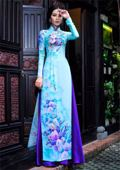
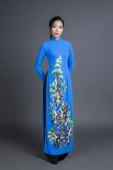
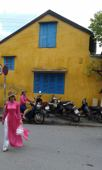
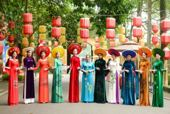
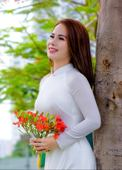
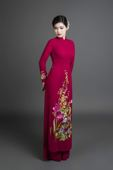
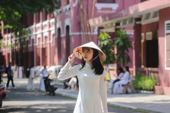
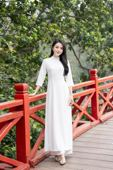
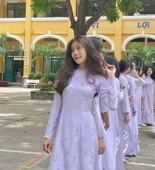
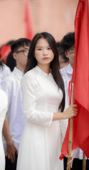
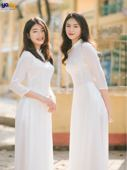
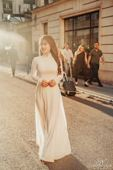

In [8]:
cmp, src = s.compare()
report.show(viz.query_comparison(cmp, cfg.search_viz.k_text, cfg.search_viz.k_images, source=src))

## Bước 2b · Bằng chứng đưa vào spec
Cột trái: KB viết tay. Cột phải: thuộc tính VLM rút từ văn bản web, mỗi dòng kèm câu gốc. Ảnh viền xanh = được chọn làm tham chiếu IP-Adapter.

nguồn,tiêu đề,độ dài
duckduckgo+page,Web: Áo dài – Wikipedia tiếng Việt,4000 ký tự
duckduckgo+page,Web: Tư liệu về Áo dài Việt Nam – Quỹ di sản,4000 ký tự
duckduckgo+page,Web: Nguồn gốc của áo dài truyền thống Việt Nam,4000 ký tự
duckduckgo,Web: Lịch sử phát triển áo dài Việt Nam qua các thời kỳ - Cổng Th,113 ký tự
duckduckgo,"Web: Cấu tạo của áo dài đầy đủ, chi tiết nhất",223 ký tự
duckduckgo,Web: Áo dài - Wikipedia,344 ký tự

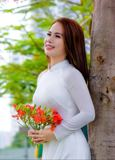
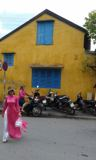
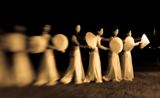
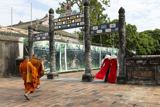
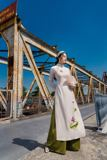
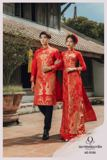

In [9]:
search, src = s.retrieve()
report.show(viz.evidence_table(search, s.kb, source=src))

## Bước 2c · Summary agent
Tóm tắt tư liệu vừa truy hồi của mỗi thực thể thành brief thị giác (facts EN/VI, khác gì với thứ dễ nhầm, một câu 'vẽ thế nào'). Chỉ được dùng thông tin trong văn bản; facts VI được kiểm mờ có câu gốc. Brief dùng cho Rank agent và (khi `agents.enrich_prompt=true`) nối vào prompt kiểu Culture-TRIP.

In [10]:
briefs, src = s.brief()
report.show(viz.brief_card(briefs, s.spec()[0], source=src))

## Bước 3 · CulturalSpec → GenSpec
Cột EN là thứ thật sự đi vào prompt SDXL (lấy từ KB viết tay, không dịch bằng VLM).

phải có (VI),phải có (EN → prompt)
"áo dài tay, thân áo xẻ hai bên từ ngang hông xuống thành hai tà trước và sau",long-sleeved tunic split at the hips into front and back panels
"cổ đứng cao (cổ trụ), ôm sát cổ",high stand-up mandarin collar
"mặc cùng quần dài ống rộng, cùng hoặc khác màu",worn over wide-legged long trousers
"phần thân trên ôm sát, tà áo buông tự do",fitted bodice with flowing loose panels
"thân áo dài được xẻ làm hai tà, vị trí xẻ tà ở hai bên hông.","(chưa dịch, bỏ khỏi prompt)"

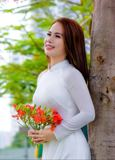

seed,1234,bước,30,guidance,6.5,kích cỡ,1024×1024,ứng viên,6


In [11]:
spec, src = s.spec()
report.show(viz.spec_card(spec, source=src))
gen, src = s.genspec()
report.show(viz.genspec_card(gen, source=src))

In [12]:
# 1xT4: giải phóng Qwen trước khi nạp model sinh ảnh. 2xT4 có thể bỏ qua cell này.
if cfg.multigen.device == cfg.llm.device:
    s.free_vlm()
viz.show(viz.vram_html())

## Bước 4 · Nhiều model cùng một GenSpec (v1.3: best-of-N, hires, PickScore)
Model nạp tuần tự (nhỏ trước), mỗi hàng hiện ngay khi xong. Dưới tên model có **số token** của prompt và **ghi chú** (scheduler, LoRA scale, compel, hires, IP-Adapter). Hàng `*_aodai` chỉ chạy khi spec có áo dài và có `CIVITAI_TOKEN`; hàng `sdxl_refplus` chỉ chạy khi có ảnh tham chiếu đạt CLIP.

Muốn sweep LoRA scale: `s.multigen(["sdxl_aodai@0.6", "sdxl_aodai@0.8", "sdxl_aodai@1.0"])` (mỗi khoá một hàng, cùng seed).

Hàng `sdxl_refplus` lấy ảnh tham chiếu đã qua **Filter agent** (bỏ ảnh nhóm khi prompt một người, bỏ ảnh không có must_have); bảng lọc hiện ngay bên dưới grid.

n_candidates=6 · scheduler=dpmpp_2m_karras · compel=True · hires=x1.5 · PickScore=True · ref_images=3
dreamshaper8     Lykon/dreamshaper-8                           512px 30 bước g7 ~2.5 GB  SD 1.5 fine-tune phổ biến; nhẹ, hỗ trợ negative. Đại diện thế hệ SD1.5
realvis_xl       SG161222/RealVisXL_V4.0                       1024px 30 bước g5 ~7.0 GB  SDXL fine-tune ảnh thực (người, vải, ánh sáng) - ứng viên thay sdxl_ba
realvis_xl#tags  SG161222/RealVisXL_V4.0                       1024px 30 bước g5 ~7.0 GB  SDXL fine-tune ảnh thực (người, vải, ánh sáng) - ứng viên thay sdxl_ba
realvis_xl#tags_w SG161222/RealVisXL_V4.0                       1024px 30 bước g5 ~7.0 GB  SDXL fine-tune ảnh thực (người, vải, ánh sáng) - ứng viên thay sdxl_ba
realvis_xl#legacy_negtags SG161222/RealVisXL_V4.0                       1024px 30 bước g5 ~7.0 GB  SDXL fine-tune ảnh thực (người, vải, ánh sáng) - ứng viên thay sdxl_ba
realvis_xl+ref   SG161222/RealVisXL_V4.0                       1024px 30 bước g5 ~7.

config.json: 0.00B [00:00, ?B/s]

`torch_dtype` is deprecated! Use `dtype` instead!


pytorch_model.bin:   0%|          | 0.00/605M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/398 [00:00<?, ?it/s]

...

Loading pipeline components...:   0%|          | 0/6 [00:00<?, ?it/s]

CLIPFeatureExtractor appears to have been deprecated in transformers. Using CLIPImageProcessor instead.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2290: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` on a `StableDiffusionPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_tiling()`.
  deprecate(


  [4b] dreamshaper8: verifier chưa đạt (attr tốt nhất 0.6414), sinh thêm 2 -> 4
  [4b] dreamshaper8: verifier chưa đạt (attr tốt nhất 0.6414), sinh thêm 2 -> 6
  [4b] dreamshaper8: hires fix x1.5 strength 0.3 -> 768px
  [4b] dreamshaper8: 6 ảnh, 80.1s, đỉnh 2.59 GB, CLIP 1.00



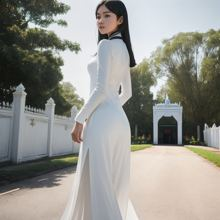
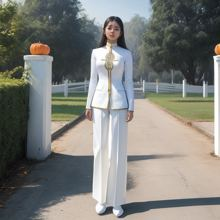
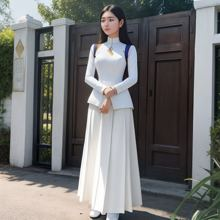
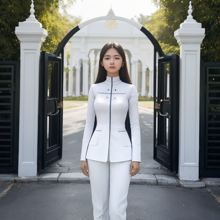
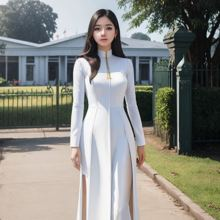
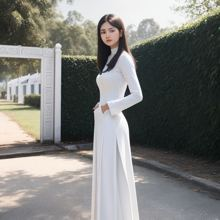

  [4b] nạp realvis_xl (SG161222/RealVisXL_V4.0) ...


config.json:   0%|          | 0.00/631 [00:00<?, ?B/s]

diffusion_pytorch_model.safetensors:   0%|          | 0.00/335M [00:00<?, ?B/s]

model_index.json:   0%|          | 0.00/577 [00:00<?, ?B/s]

Fetching 16 files:   0%|          | 0/16 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2263: FutureWarning: `enable_vae_slicing` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_slicing()` on a `StableDiffusionXLPipeline` is deprecated and this method will be removed in a future version. Please use `pipe.vae.enable_slicing()`.
  deprecate(
/usr/local/lib/python3.12/dist-packages/diffusers/pipelines/pipeline_utils.py:2290: FutureWarning: `enable_vae_tiling` is deprecated and will be removed in version 0.40.0. Calling `enable_vae_tiling()` 

  [4b] realvis_xl: verifier chưa đạt (attr tốt nhất 0.6687), sinh thêm 2 -> 4
  [4b] realvis_xl: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_xl: 4 ảnh, 254.4s, đỉnh 13.37 GB, CLIP 1.00



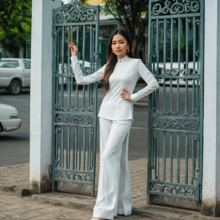
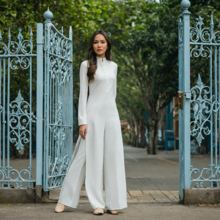
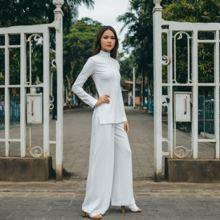
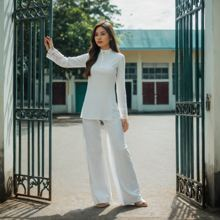

  [4b] nạp realvis_xl#tags (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [4b] realvis_xl#tags: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_xl#tags: 2 ảnh, 114.5s, đỉnh 13.37 GB, CLIP 1.00



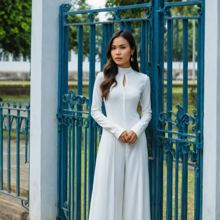
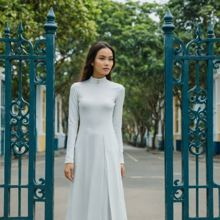

  [4b] nạp realvis_xl#tags_w (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Deprecation warning: passing multiple tokenizers/text encoders to Compel is deprecated and will be removed in v3.0. Use one of the CompelFor* classes in multi_model_wrappers instead
  [4b] realvis_xl#tags_w: verifier chưa đạt (attr tốt nhất 0.6161), sinh thêm 2 -> 4
  [4b] realvis_xl#tags_w: verifier chưa đạt (attr tốt nhất 0.6161), sinh thêm 2 -> 6
  [4b] realvis_xl#tags_w: nhấn compel: fitted long tunic×1.2
  [4b] realvis_xl#tags_w: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_xl#tags_w: 6 ảnh, 336.0s, đỉnh 13.37 GB, CLIP 1.00



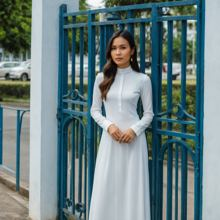
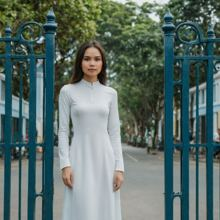
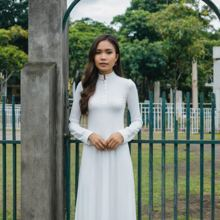
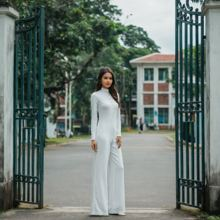
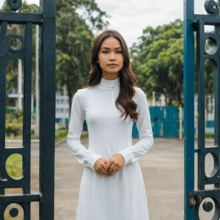
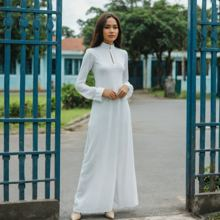

  [4b] nạp realvis_xl#legacy_negtags (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [4b] realvis_xl#legacy_negtags: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_xl#legacy_negtags: 2 ảnh, 114.1s, đỉnh 13.37 GB, CLIP 1.00



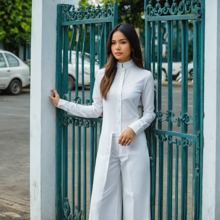
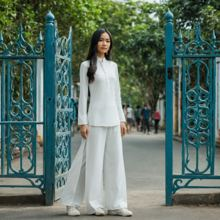

  [4b] realvis_xl+ref: auto_ref: prior 0.55 > 0.45 -> model tự vẽ được, không dùng ảnh (tránh chép) -> hàng chạy KHÔNG ảnh tham chiếu
  [4b] nạp realvis_xl+ref (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [4b] realvis_xl+ref: verifier chưa đạt (attr tốt nhất 0.6687), sinh thêm 2 -> 4
  [4b] realvis_xl+ref: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_xl+ref: 4 ảnh, 224.2s, đỉnh 13.37 GB, CLIP 1.00



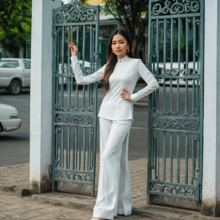
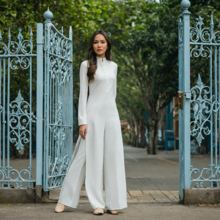
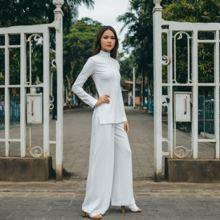
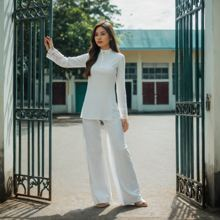

  [4b] nạp sdxl_aodai (stabilityai/stable-diffusion-xl-base-1.0) ...


model_index.json:   0%|          | 0.00/609 [00:00<?, ?B/s]

Fetching 17 files:   0%|          | 0/17 [00:00<?, ?it/s]

Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new


  [4b] sdxl_aodai: LoRA gắn xong (peft adapter, scale 0.8)
  [4b] sdxl_aodai: verifier chưa đạt (attr tốt nhất 0.6951), sinh thêm 2 -> 4
  [4b] sdxl_aodai: verifier chưa đạt (attr tốt nhất 0.6951), sinh thêm 2 -> 6
  [4b] sdxl_aodai: hires fix x1.5 strength 0.3 -> 1536px
  [4b] sdxl_aodai: 6 ảnh, 442.3s, đỉnh 13.45 GB, CLIP 1.00



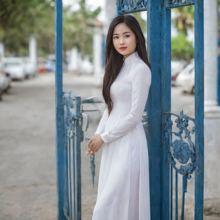
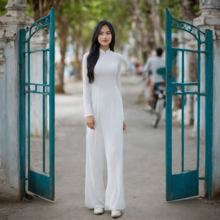
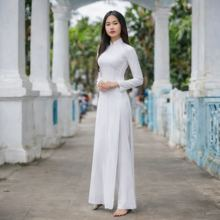
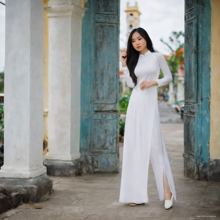
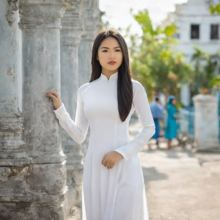
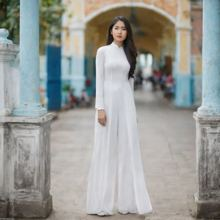

  [4b] nạp realvis_aodai (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
No LoRA keys associated to CLIPTextModel found with the prefix='text_encoder'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModel related params. You can also try specifying `prefix=None` to resolve the warning. Otherwise, open an issue if you think it's unexpected: https://github.com/huggingface/diffusers/issues/new
No LoRA keys associated to CLIPTextModelWithProjection found with the prefix='text_encoder_2'. This is safe to ignore if LoRA state dict didn't originally have any CLIPTextModelWithProjection related params. 

  [4b] realvis_aodai: LoRA gắn xong (peft adapter, scale 0.8)
  [4b] realvis_aodai: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_aodai: 2 ảnh, 158.8s, đỉnh 13.45 GB, CLIP 1.00



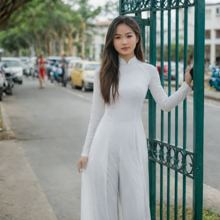
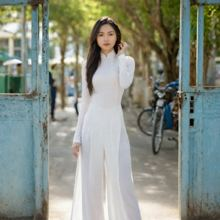

  [4b] realvis_aodai+ref: auto_ref: prior 0.55 > 0.45 -> model tự vẽ được, không dùng ảnh (tránh chép) -> hàng chạy KHÔNG ảnh tham chiếu
  [4b] nạp realvis_aodai+ref (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [4b] realvis_aodai+ref: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_aodai+ref: 2 ảnh, 154.0s, đỉnh 13.45 GB, CLIP 1.00



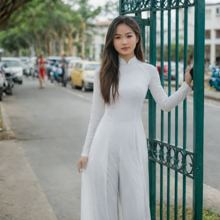
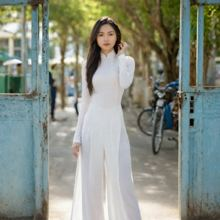

  [4b] nạp sdxl_refplus (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

models/image_encoder/model.safetensors:   0%|          | 0.00/2.53G [00:00<?, ?B/s]

Loading weights:   0%|          | 0/520 [00:00<?, ?it/s]

CLIPVisionModelWithProjection LOAD REPORT from: h94/IP-Adapter
Key                                  | Status     |  | 
-------------------------------------+------------+--+-
vision_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


  [4b] sdxl_refplus: IP-Adapter Plus (ViT-H) scale 0.4, 2 ảnh tham chiếu: d9389666c0728421.jpg, 185dd549cde8ee47.jpg
  [4b] sdxl_refplus: LỖI RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:1 (when checking argument in method wrapper_CUDA__index_select)


model,ứng viên (viền xanh = điểm tổng cao nhất trong hàng)
"sdxl_refplusRealVisXL_V4.030 bước · g5 · 1024px59s· scheduler DPMSolverMultistepScheduler· IP-Adapter Plus (ViT-H) scale 0.4, 2 ảnh tham chiếu· hires tắt cho hàng IP-Adapter (VRAM)· VRAM sau giải phóng 0.01 GB","RuntimeError: Expected all tensors to be on the same device, but got index is on cpu, different from other tensors on cuda:1 (when checking argument in method wrapper_CUDA__index_select)"



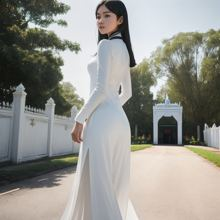
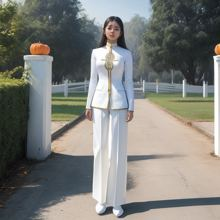
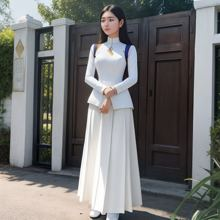
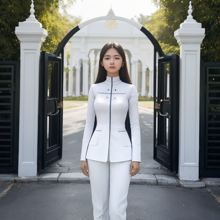
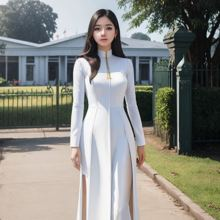
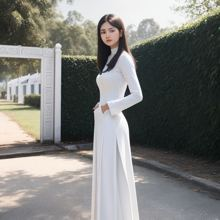
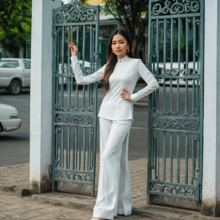
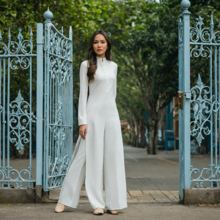
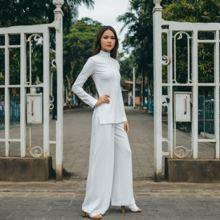
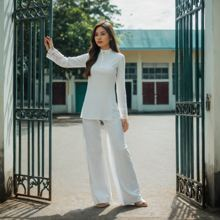
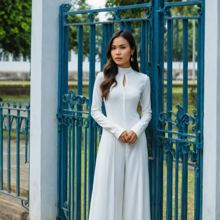
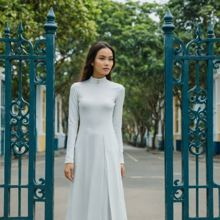
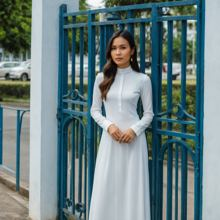
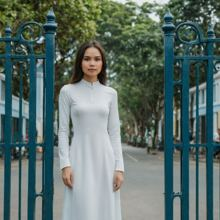
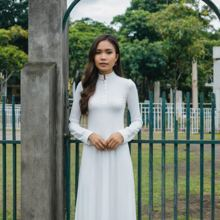
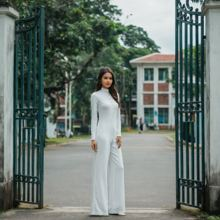
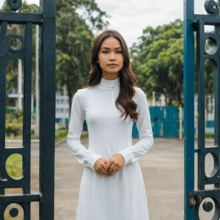
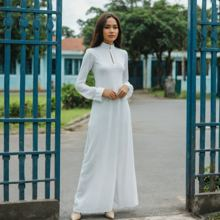
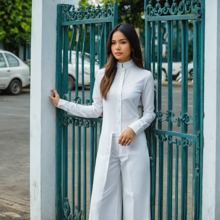
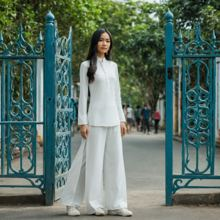
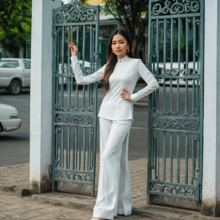
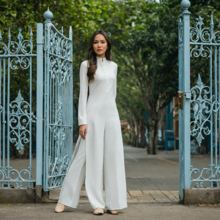
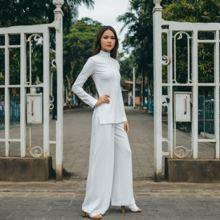
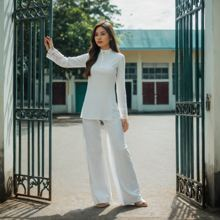
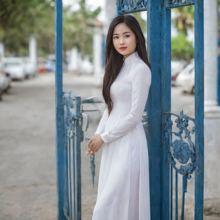
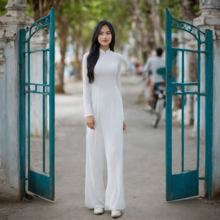
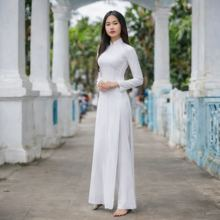
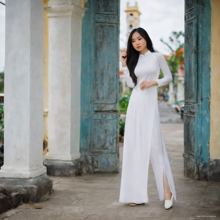
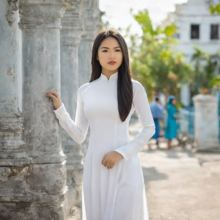
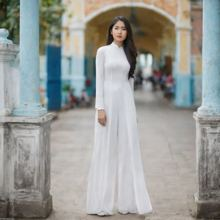
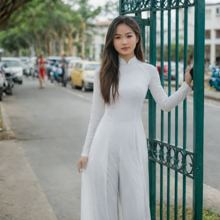
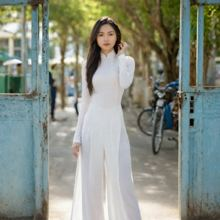
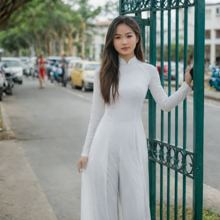
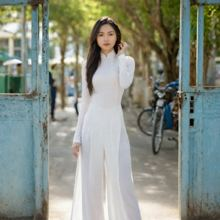


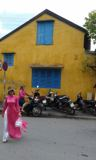
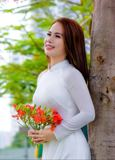
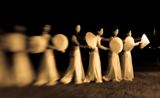

In [13]:
from ctig.models.registry import get
from ctig.schema import MultiGenResult
mg = cfg.multigen
print(f"n_candidates={mg.n_candidates} · scheduler={mg.scheduler} · compel={mg.long_prompt} · hires={'x'+str(mg.hires.scale) if mg.hires.enabled else 'tắt'} · PickScore={mg.aesthetic.enabled} · ref_images={mg.ref_images}")
for k in cfg.models:
    m = get(k); print(f"{k:16} {m.repo:45} {m.width}px {m.steps} bước g{m.guidance:g} ~{m.est_vram_gb} GB  {m.notes[:70]}")

res, src = s.multigen(cfg.models, on_model_done=lambda r: viz.show(viz.model_grid(MultiGenResult(prompt.id, [r]), spec)))
report.show(viz.model_grid(res, spec, source=src))
viz.show(viz.vram_html())

# Bước 3b: ảnh tham chiếu sau Filter agent (chỉ khi có hàng IP-Adapter và agents.ref_filter bật)
if cfg.agents.enabled and cfg.agents.ref_filter and "ref_filter" in s.steps:
    report.show(viz.filter_table(s.steps["ref_filter"].value, title="Bước 3b · Filter agent trên ảnh tham chiếu", source=s.steps["ref_filter"].source))

## Bước 5 · Bảng điểm
CLIP identity: P(ảnh giống mô tả thực thể Việt) so với các confusable. ITM: BLIP-2, họ model khác reviewer. sim: cosine CLIP với prompt tiếng Anh. Ba số để xếp thứ tự, kết luận vẫn phải nhìn grid.

In [14]:
report.show(viz.score_table(res, source=src))

model,ứng viên,hạng ensemble,tổng,CLIP identity,CLIP attr,ITM,ITM attr,đẹp (PickScore),sim(prompt),giống ref,giây,VRAM đỉnh
dreamshaper8,0,0.364,0.748,0.998,0.611,0.997,0.935,0.448 (24.7),0.339,0.707,80,2.59 GB
dreamshaper8,1,0.235,0.615,0.999,0.641,0.995,0.821,0.000 (23.6),0.382,0.683,80,2.59 GB
dreamshaper8,2,0.273,0.625,0.952,0.386,0.996,0.983,0.181 (24.0),0.379,0.702,80,2.59 GB
dreamshaper8,3,0.136,0.641,0.993,0.443,0.984,0.787,0.341 (24.4),0.342,0.659,80,2.59 GB
dreamshaper8,4,0.318,0.738,0.998,0.240,0.999,0.930,0.785 (25.4),0.383,0.728,80,2.59 GB
dreamshaper8,5,0.288,0.680,0.998,0.284,0.995,0.936,0.501 (24.8),0.359,0.732,80,2.59 GB
realvis_xl,0,0.394,0.714,1.000,0.640,0.999,0.920,0.297 (24.3),0.384,0.765,254,13.37 GB
realvis_xl,1,0.576,0.763,1.000,0.669,1.000,0.955,0.430 (24.6),0.373,0.734,254,13.37 GB
realvis_xl,2,0.455,0.662,1.000,0.725,1.000,0.866,0.059 (23.7),0.357,0.749,254,13.37 GB
realvis_xl,3,0.689,0.859,0.999,0.699,1.000,0.971,0.767 (25.4),0.361,0.762,254,13.37 GB


## Bước 4c–4d · Agent loop review (v1.4): Filter → Rank → một vòng sửa
Đúng ba ô trong sơ đồ gốc. **Filter agent**: VLM chỉ *mô tả* từng ảnh top-k (số người, trang phục, vật, nền), rồi một agent văn bản so mô tả với must_have/must_not và phải trích được cụm trong mô tả; ảnh có must_not hoặc sai số người bị bỏ. **Rank agent** xếp phần còn lại từ mô tả + brief, đối chiếu với xếp hạng theo metric (top-1 trùng không, Spearman). Ứng viên đầu còn lỗi thì lập kế hoạch sửa bằng luật (thiếu gì thêm vào prompt, thấy must_not gì thêm vào negative) và sinh lại **một** lần trên model tốt nhất; chỉ đổi ảnh cuối khi ảnh mới sạch hơn thật. Trên 1×T4 cell này nạp lại Qwen (~1 phút).

  [multigen] cache đĩa có hàng lỗi/thiếu -> chạy lại bước (ảnh của hàng tốt vẫn tái dùng)
  [3c] ảnh tham chiếu: cắt 2/2 về vùng 'a woman wearing a Vietnamese ao dai, a long fitted' (owlvit)
  [4b] dreamshaper8: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] realvis_xl: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] realvis_xl#tags: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] realvis_xl#tags_w: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] realvis_xl#legacy_negtags: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] realvis_xl+ref: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] sdxl_aodai: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] realvis_aodai: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] realvis_aodai+ref: dùng lại ảnh trên đĩa (GenSpec không đổi)
  [4b] nạp sdxl_refplus (SG161222/RealVisXL_V4.0) ...


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/517 [00:00<?, ?it/s]

CLIPTextModelWithProjection LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder_2
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

...

Loading weights:   0%|          | 0/196 [00:00<?, ?it/s]

CLIPTextModel LOAD REPORT from: /root/.cache/huggingface/hub/models--SG161222--RealVisXL_V4.0/snapshots/26dfe44930964cd70d0a817b6d1cc945c130e38d/text_encoder
Key                                | Status     |  | 
-----------------------------------+------------+--+-
text_model.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


Deprecation warning: passing multiple tokenizers/text encoders to Compel is deprecated and will be removed in v3.0. Use one of the CompelFor* classes in multi_model_wrappers instead


Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors
Token indices sequence length is longer than the specified maximum sequence length for this model (78 > 77). Running this sequence through the model will result in indexing errors


  [4b] realvis_xl+ref: compel lỗi (AttributeError: 'EmbeddingsProviderMulti' object has no attribute 'empty_z') -> dùng prompt thô, có thể bị cắt
  [4b] realvis_xl+ref: hires fix x1.5 strength 0.3 -> 1536px
  [4b] realvis_xl+ref: 2 ảnh, 139.3s, đỉnh 13.37 GB, CLIP 1.00
  [filter:candidate] giữ 1/2, prompt nói rõ 1 người


#,ảnh,hạng metric,hạng agent,lý do agent
1,p001_realvis_xl_c3_hr,1,3,Ao dai is correctly represented as a long-sleeved dress with a fitted bodice and flowing loose panels.
2,p001_realvis_aodai_c1_hr,4,1,Ao dai is correctly represented as a long-sleeved dress with a fitted bodice and flowing loose panels.
3,p001_realvis_xl_ref_c3_hr,2,4,Ao dai is correctly represented as a long-sleeved dress with a fitted bodice and flowing loose panels.
4,p001_realvis_aodai_ref_c1_hr,5,2,Ao dai is correctly represented as a long-sleeved dress with a fitted bodice and flowing loose panels.
5,p001_realvis_xl_rtags_c0_hr,3,5,Ao dai is correctly represented as a long-sleeved dress with a fitted bodice and flowing loose panels.

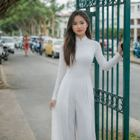
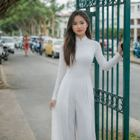
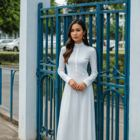
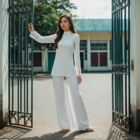
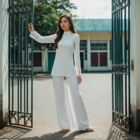
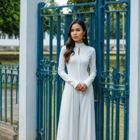
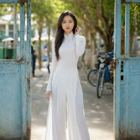
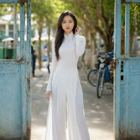
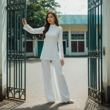
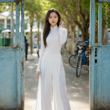
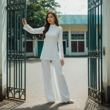
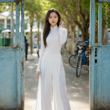
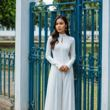
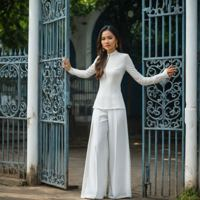
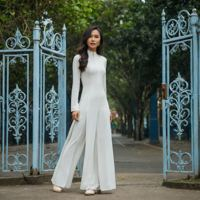
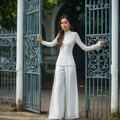
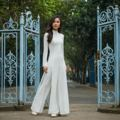
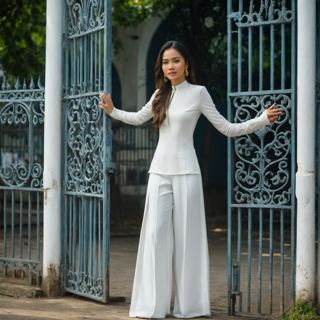

In [15]:
cr, src = s.candidate_review()
report.show(viz.candidate_review_html(cr, source=src))

## Bước 5b · Vòng review agent (tuỳ chọn)
Tắt mặc định vì VLM 3B trả lời checklist thiên lệch (xem research/research-log.md). Đặt `RUN_REVIEW = True` ở cell prompt để chạy.

In [16]:
if RUN_REVIEW:
    outcome, src = s.review()
    report.show(viz.review_summary(outcome, spec, source=src))
else:
    print("bỏ qua (RUN_REVIEW=False)")

bỏ qua (RUN_REVIEW=False)


## Xuất
`walkthrough.html` là toàn bộ các bảng phía trên trong một file (ảnh đã nhúng). `runs_cache.zip` để lần sau khôi phục cache.

In [17]:
out = report.save(s.out_dir / "walkthrough.html")
# Zip CẢ ảnh đã sinh (runs/walkthrough) lẫn cache, vì Kaggle xoá /kaggle/working giữa hai phiên; thiếu ảnh cũ thì bước 4 sinh lại toàn bộ.
!cd /kaggle/working && rm -f runs_cache.zip && zip -qr runs_cache.zip runs/_cache runs/walkthrough -x '*/grid_hires.png' && ls -lh runs_cache.zip
from IPython.display import FileLink, display
display(FileLink(str(out)))
display(FileLink(str(s.out_dir / "grid.png")))
display(FileLink("/kaggle/working/runs_cache.zip"))
print("llm cache:", __import__('ctig.llm.cache', fromlist=['current']).current().stats())

# Báo cáo tiến độ gửi người hướng dẫn: HTML tự chứa, ảnh độ phân giải gốc, bảng/biểu đồ vector, kèm grid_hires.png cho slide.
from ctig.progress_report import build
build(str(s.run_dir), "/kaggle/working/progress_report.html",   # gom MỌI prompt đã chạy trong runs/walkthrough
      title="CTIG - Cultural T2I (Việt Nam): báo cáo tiến độ", cfg=cfg)
display(FileLink("/kaggle/working/progress_report.html")); display(FileLink(str(s.out_dir / "grid_hires.png")))

-rw-r--r-- 1 root root 249M Sep 13 09:17 runs_cache.zip


/kaggle/working/runs/walkthrough/p001/walkthrough.html

/kaggle/working/runs/walkthrough/p001/grid.png

/kaggle/working/runs_cache.zip

llm cache: llm cache: 6 hit / 15 miss
[report] grid nét: /kaggle/working/runs/walkthrough/p001/grid_hires.png
[report] /kaggle/working/progress_report.html (10.8 MB, 1 prompt)


/kaggle/working/progress_report.html

/kaggle/working/runs/walkthrough/p001/grid_hires.png